# INSTITUTO FEDERAL DO NORTE DE MINAS GERAIS - Campus Montes Claros
**Disciplina:** Processamento Digital de Imagens  
**Tema:** Atividade Prática 2b - Filtragem Espacial  
**Professor:** Wagner Ferreira de Barros  
**Data:** 03/05/2026  
**Integrantes:** Gabriel Davi Mota Baia e Lucas Santos Ribeiro

In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [70]:
# Funções customizadas para cálculo de métricas usando apenas NumPy

def mse(img1, img2): # Cálculo do MSE usando apenas NumPy
    err = np.sum((img1.astype("float") - img2.astype("float")) ** 2)
    err /= float(img1.shape[0] * img1.shape[1])
    return err

def psnr(img1, img2): # Cálculo do PSNR usando a função MSE personalizada
    erro_mse = mse(img1, img2)

    if erro_mse == 0:
        return 100 
    
    pixel_maximo = 255.0
    return 20 * np.log10(pixel_maximo / np.sqrt(erro_mse))

def add_salt_and_pepper_noise(image, prob): # Adiciona ruído sal e pimenta a uma imagem
    noisy = np.copy(image)
    num_salt = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape[:2]]
    noisy[tuple(coords)] = 255
    num_pepper = np.ceil(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape[:2]]
    noisy[tuple(coords)] = 0
    return noisy

img_original = cv2.imread('image-cinza-lago.jpg', cv2.IMREAD_GRAYSCALE)

if img_original is None:
    print("ERRO: Certifique-se de que o arquivo 'image-cinza-lago.jpg' está na mesma pasta do Jupyter Notebook.")
else:
    print("Imagem carregada com sucesso!")

Imagem carregada com sucesso!


Questão 1 - Suavização por Média

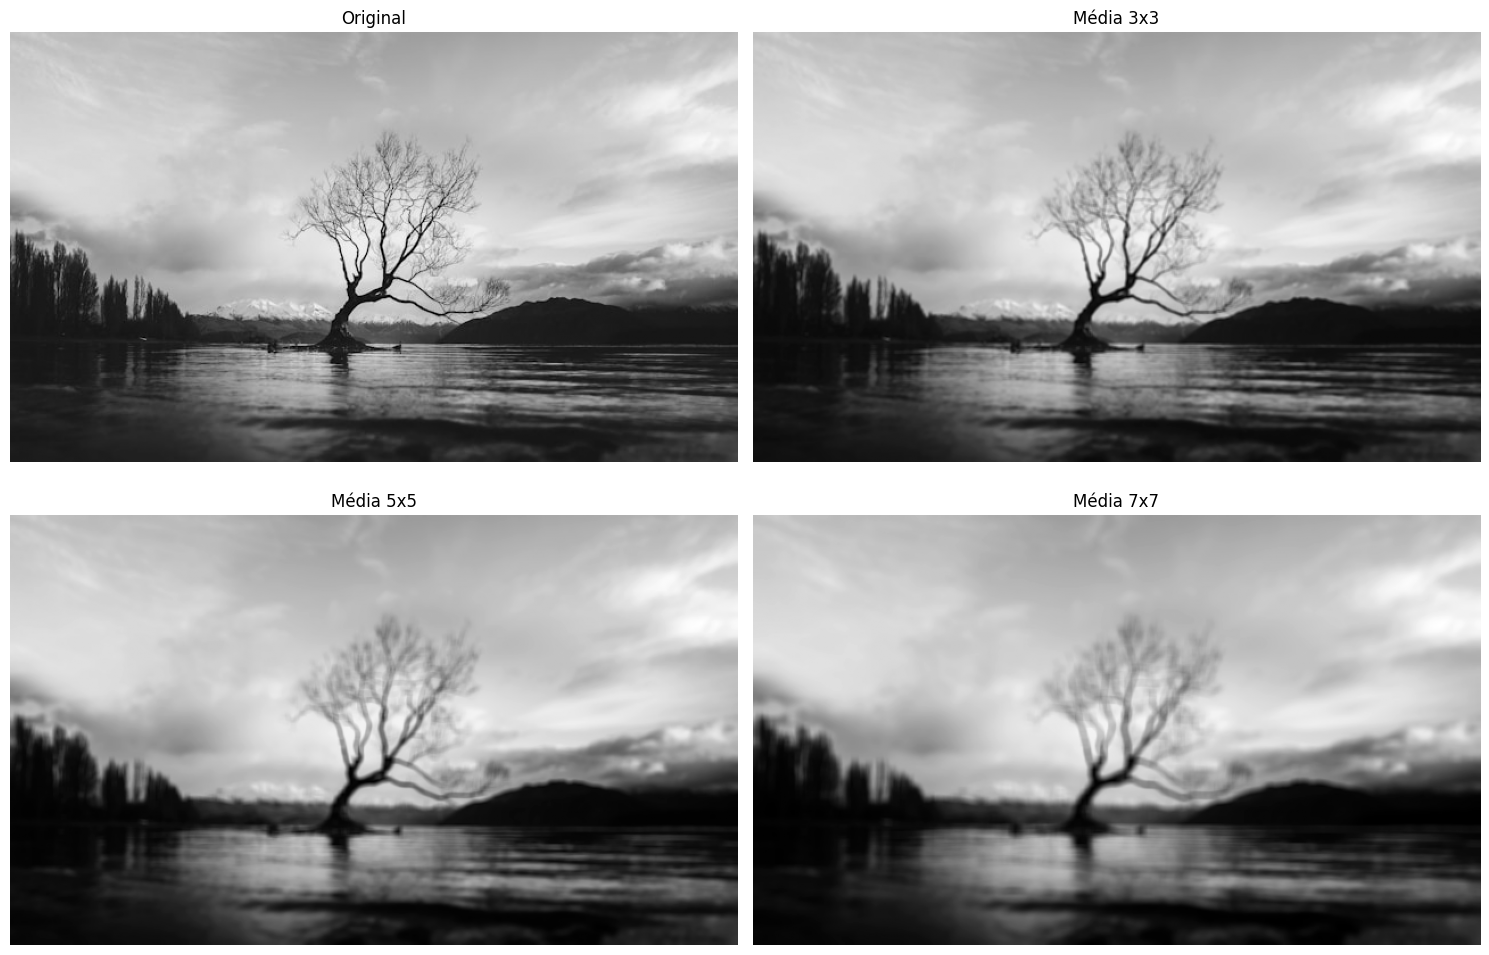

In [71]:
# Aplicação do filtro de média com diferentes tamanhos de kernel
blur_3x3 = cv2.blur(img_original, (3, 3)) 
blur_5x5 = cv2.blur(img_original, (5, 5))
blur_7x7 = cv2.blur(img_original, (7, 7))

# Exibição
q1_images = [img_original, blur_3x3, blur_5x5, blur_7x7]
q1_titles = ['Original', 'Média 3x3', 'Média 5x5', 'Média 7x7']
plot_images(q1_images, q1_titles)

Questão 2 - Ruído Sal e Pimenta e Mediana

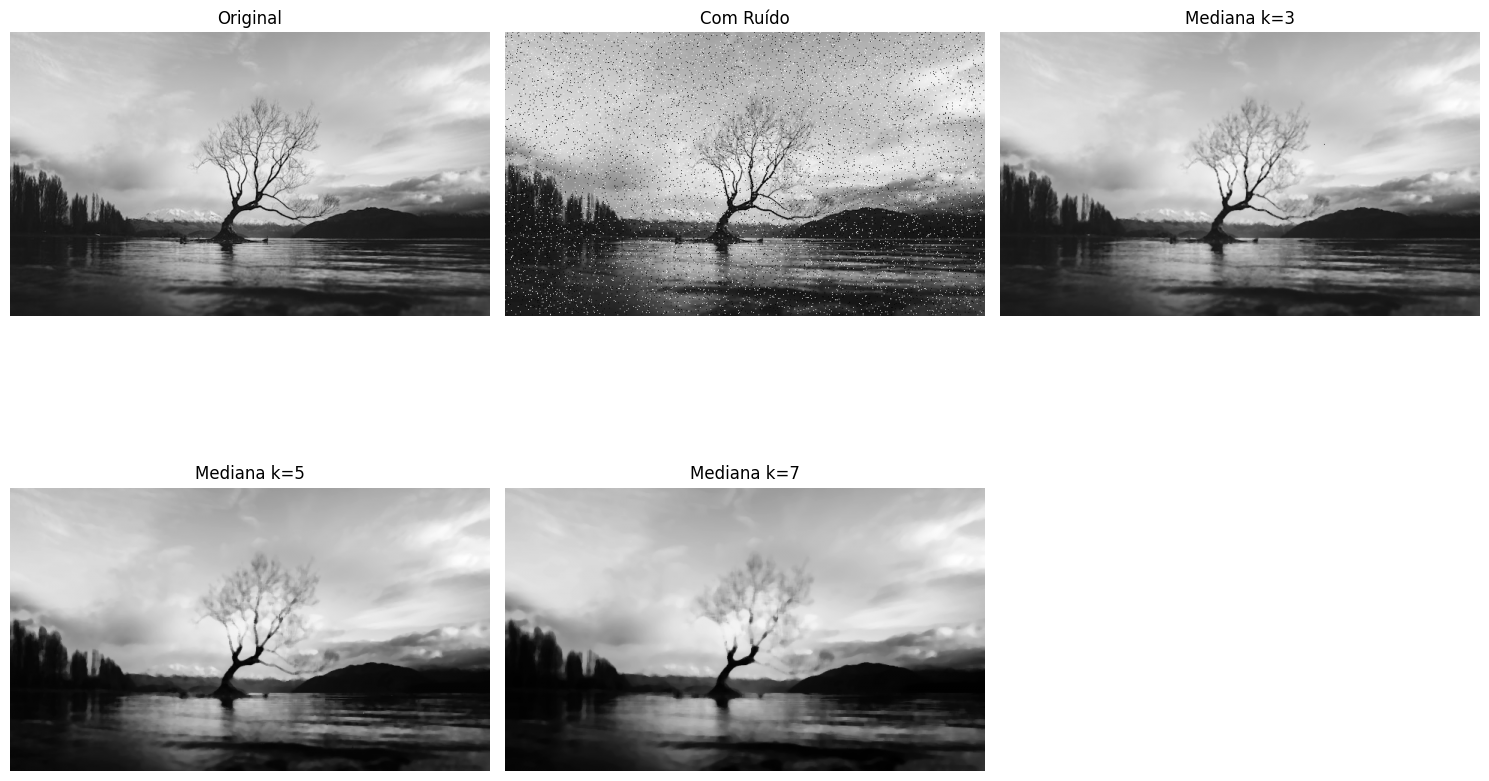

--- Análise Objetiva (PSNR e MSE) ---
Ruído vs Original       -> MSE: 1064.10 | PSNR: 17.86 dB
Mediana k=3 vs Original -> MSE: 50.96 | PSNR: 31.06 dB
Mediana k=5 vs Original -> MSE: 112.28 | PSNR: 27.63 dB
Mediana k=7 vs Original -> MSE: 162.81 | PSNR: 26.01 dB


In [ ]:
img_ruido = add_salt_and_pepper_noise(img_original, prob=0.05) # Adicionando ruído sal e pimenta

mediana_3 = cv2.medianBlur(img_ruido, 3) # Aplicando filtro de mediana com diferentes tamanhos de kernel
mediana_5 = cv2.medianBlur(img_ruido, 5)
mediana_7 = cv2.medianBlur(img_ruido, 7)

plot_images( # Exibindo os resultados da mediana
    [img_original, img_ruido, mediana_3, mediana_5, mediana_7],
    ["Original", "Com Ruído", "Mediana k=3", "Mediana k=5", "Mediana k=7"],
    columns=3
)

# Análise Objetiva (Métricas)
print("--- Análise Objetiva (PSNR e MSE) ---")
print(f"Ruído vs Original       -> MSE: {mse(img_original, img_ruido):.2f} | PSNR: {psnr(img_original, img_ruido):.2f} dB")
print(f"Mediana k=3 vs Original -> MSE: {mse(img_original, mediana_3):.2f} | PSNR: {psnr(img_original, mediana_3):.2f} dB")
print(f"Mediana k=5 vs Original -> MSE: {mse(img_original, mediana_5):.2f} | PSNR: {psnr(img_original, mediana_5):.2f} dB")
print(f"Mediana k=7 vs Original -> MSE: {mse(img_original, mediana_7):.2f} | PSNR: {psnr(img_original, mediana_7):.2f} dB")

Questão 3 - Combinação de Filtros (Cascata)

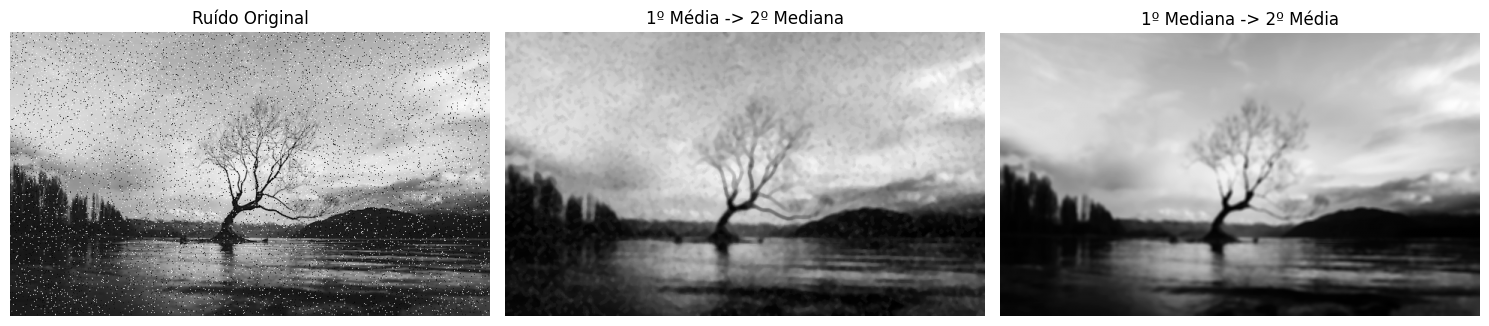

In [73]:
cascata_media_mediana = cv2.medianBlur(cv2.blur(img_ruido, (5, 5)), 5) # Aplicando média seguida de mediana

cascata_mediana_media = cv2.blur(cv2.medianBlur(img_ruido, 5), (5, 5)) # Aplicando mediana seguida de média

plot_images(
    [img_ruido, cascata_media_mediana, cascata_mediana_media],
    ["Ruído Original", "1º Média -> 2º Mediana", "1º Mediana -> 2º Média"],
    columns=3
)

Questão 4 e 5 - Domínio de Cor e Análise Crítica

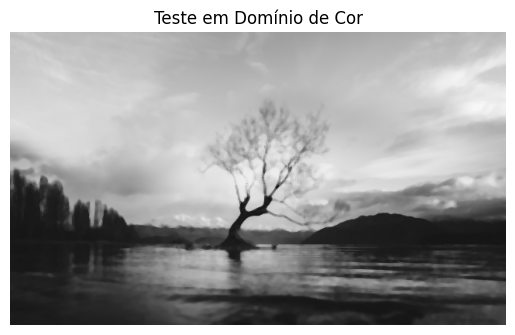

In [74]:
img_color_example = cv2.cvtColor(img_original, cv2.COLOR_GRAY2BGR) # Simulando colorida
color_filtered = cv2.medianBlur(img_color_example, 5) # Aplicando mediana em uma imagem colorida (BGR)

plt.imshow(cv2.cvtColor(color_filtered, cv2.COLOR_BGR2RGB))
plt.title("Teste em Domínio de Cor")
plt.axis('off')
plt.show()

Analise Questões

Questão 01: Foi utilizada a função cv2.blur para realizar a média aritmética na vizinhança. Observa-se que o aumento do kernel resulta em uma perda progressiva de nitidez, especialmente visível nos galhos finos da árvore, confirmando o comportamento de um filtro passa-baixa.

Questão 02: O filtro da mediana mostrou-se extremamente eficaz na remoção do ruído impulsivo. O PSNR subiu de {psnr_noisy:.2f}dB para {psnr_m3:.2f}dB, indicando uma restauração fiel da imagem original com mínima perda de bordas.

Questão 03: A ordem dos fatores altera o resultado. Aplicar a média primeiro borra os pontos de ruído, tornando-os manchas que a mediana não consegue remover totalmente. Já a mediana primeiro remove o ruído com precisão, permitindo que a média suavize a imagem limpa.

Questão 04 e 05: O filtro de média é indicado para suavização e ruídos uniformes, mas sacrifica bordas. O filtro de mediana é indispensável para ruídos do tipo Sal e Pimenta, preservando a estrutura da imagem (bordas) de forma superior.